In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# from IPython.core.display import display, HTML
# display(HTML("<style>.output_scroll{height: auto !important;}</style>"))

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [4]:
df=pd.read_excel('Ti6Al4V-NiTi单道沉积试样实验测量熔池形貌数据汇总.xlsx',sheet_name='Sheet1')
df

,试样标号,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）,右润湿角（°）
0,A-1,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315,99.836
1,A-2,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671,91.650
2,A-3,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036,87.592
3,A-4,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068,98.973
4,A-5,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094,134.676
5,A-6,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679,112.818
6,A-7,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851,85.486
7,A-8,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434,87.241
8,A-9,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851,128.480
9,A-10,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607,81.174


# Predict Molten Pool Width

In [5]:
df_width = df.drop(df.columns[[0, 7, 8, 9, 10, 11]], axis=1)
df_width

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）
0,0.0,600,200,1.000000,90.000000,2803.604
1,0.0,700,200,1.000000,105.000000,3189.189
2,0.0,800,200,1.000000,120.000000,3654.054
3,0.0,900,200,1.000000,135.000000,4075.676
4,0.0,600,250,0.600000,72.000000,2661.111
5,0.0,700,250,0.600000,84.000000,3124.074
6,0.0,800,250,0.600000,96.000000,3549.550
7,0.0,900,250,0.600000,108.000000,3960.360
8,0.0,600,300,0.333333,60.000000,2631.776
9,0.0,700,300,0.333333,70.000000,3018.692


In [6]:
df_width.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,2814.882050
std,0.342997,167.574558,71.00716,0.356285,24.505039,633.983643
min,0.000000,350.000000,200.00000,0.000000,26.250000,1672.222000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,2293.332500
50%,0.500000,600.000000,300.00000,0.333333,60.000000,2800.867500
75%,0.800000,725.000000,350.00000,0.600000,77.857143,3319.342750
max,1.000000,900.000000,400.00000,1.000000,135.000000,4198.198000


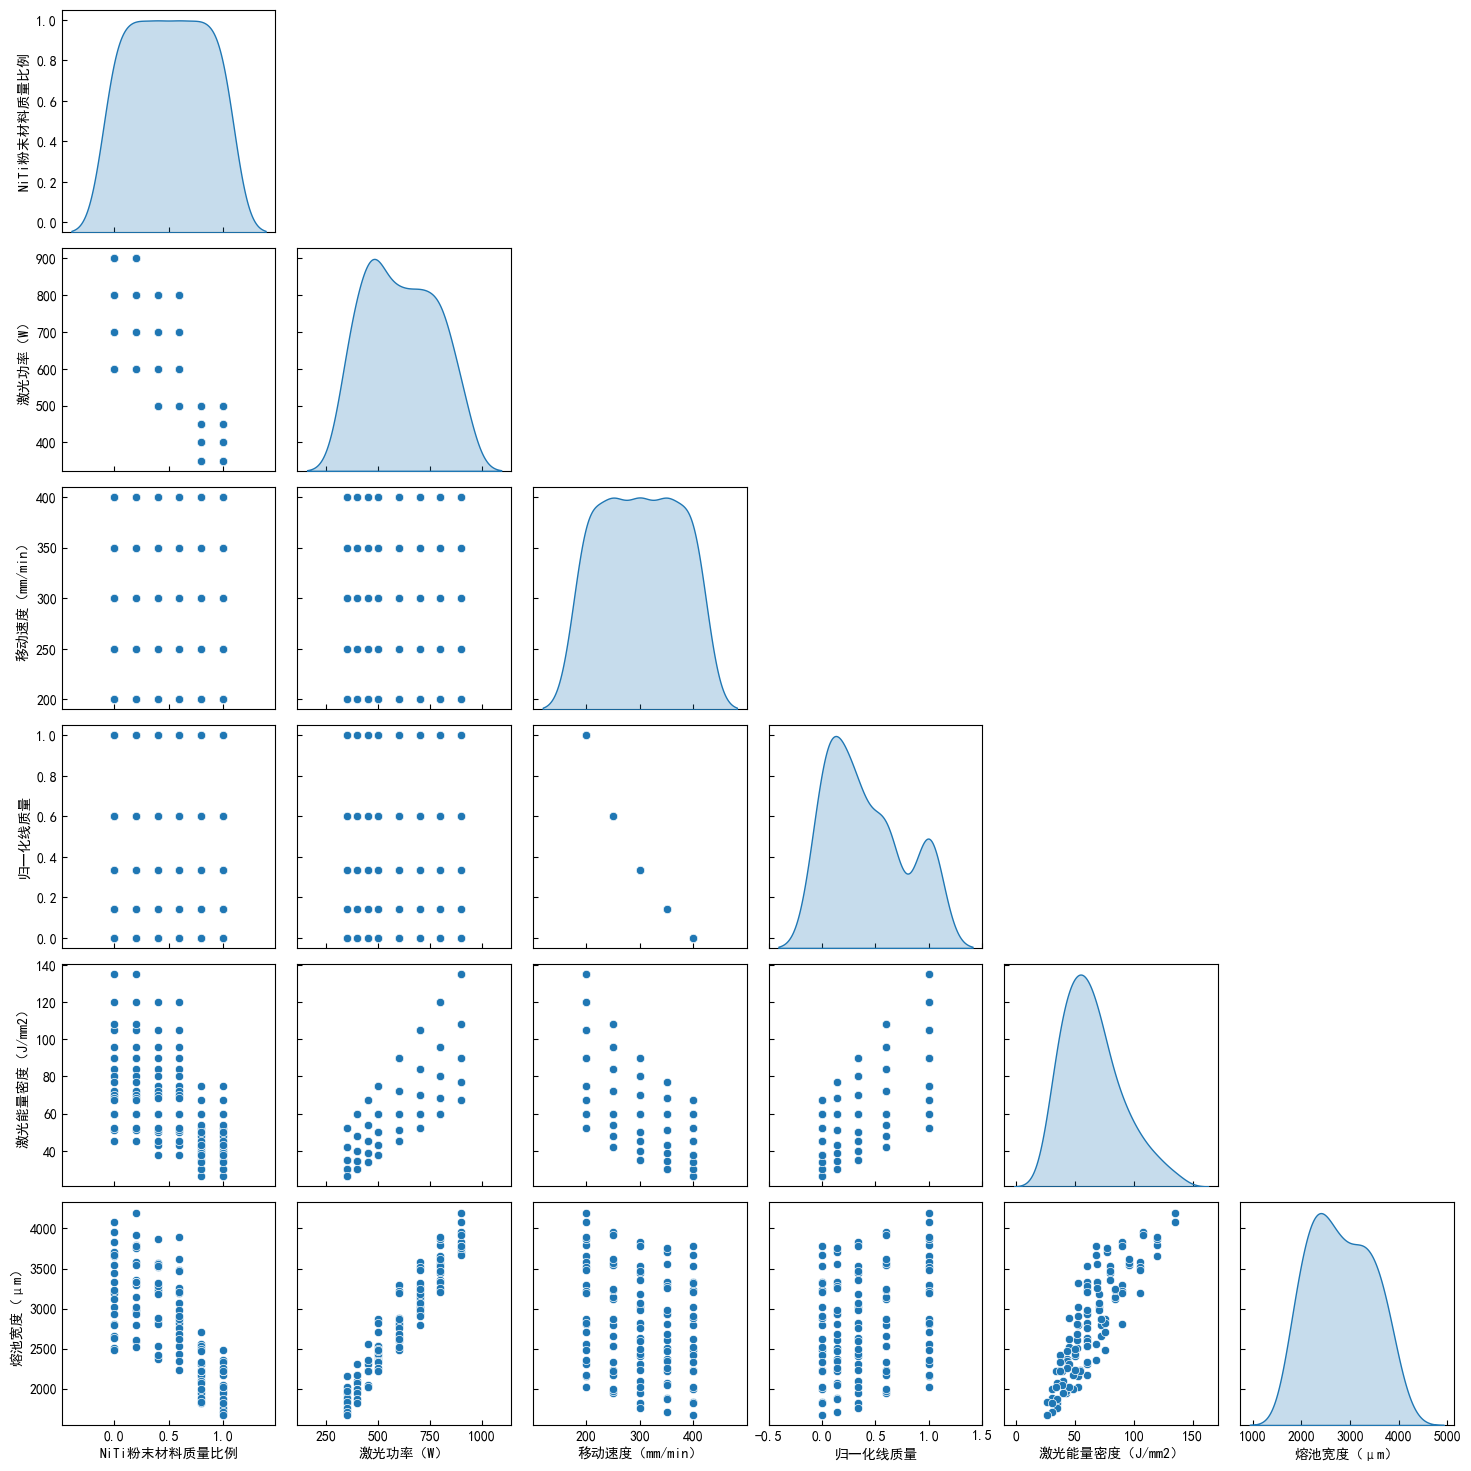

In [7]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_width, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

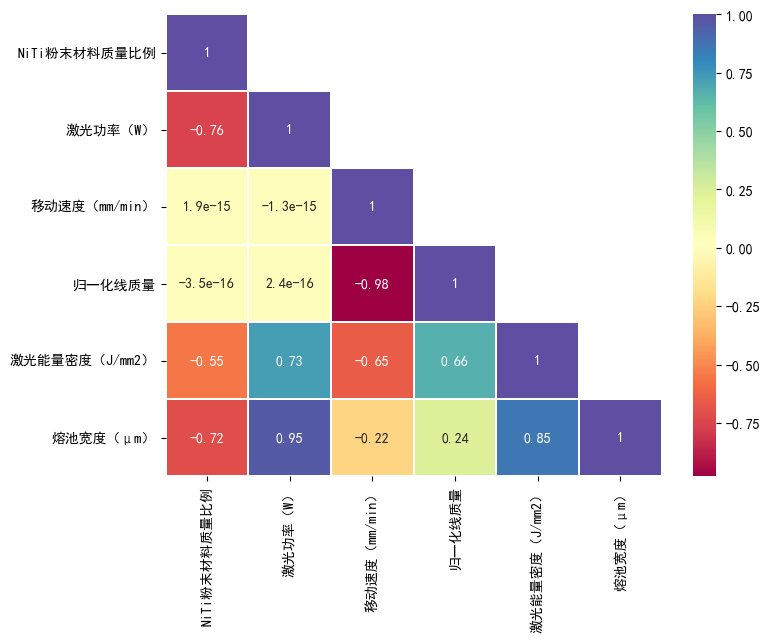

In [8]:
corr = df_width.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [9]:
X = df_width.iloc[:, :-1]
y = df_width.iloc[:, -1]

In [10]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBRegressor

In [11]:
def model_with_random_search(X, y, model, param_dist, scoring='neg_mean_squared_error', cv_splits=4, n_iter=5000):
   
    kfold = KFold(n_splits=cv_splits, shuffle=True, random_state=10)

    random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=n_iter, 
                                     cv=kfold, scoring=scoring, random_state=10, n_jobs=-1, verbose=1)

    random_search.fit(X, y)

    print('最优超参数:', random_search.best_params_)
    print('最佳超参数下的均方误差:', np.sqrt(-random_search.best_score_))

    return random_search.best_estimator_


In [12]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 91.8805
基准LinearRegression模型均方根误差: 105.5372
基准Lasso模型均方根误差: 103.4072
基准Ridge模型均方根误差: 106.6295
基准RandomForestRegressor模型均方根误差: 122.8579
基准SVR模型均方根误差: 88.5964
基准MLPRegressor模型均方根误差: 97.0625
基准KNeighborsRegressor模型均方根误差: 132.3902

表现最好的基准模型是: SVR，其均方根误差为: 88.5964


In [13]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.4, 'gamma': 0, 'colsample_bytree': 0.5}
最佳超参数下的均方误差: 95.93762309865382
最佳模型在测试数据上的均方误差: 85.5353


In [14]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 8, 'reg_lambda': 5, 'reg_alpha': 10, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'thrifty'}
最佳超参数下的均方误差: 118.07456989810336
最佳模型在测试数据上的均方误差: 112.8609


In [15]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.7, 'skip_drop': 0.4, 'sample_type': 'uniform', 'rate_drop': 0.1, 'normalize_type': 'tree', 'n_estimators': 250, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.4, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 93.67600641029875
最佳模型在测试数据上的均方误差: 85.3231


## Predict Molten Pool Depth

In [16]:
df_depth = df.drop(df.columns[[0, 6, 8, 9, 10, 11]], axis=1)
df_depth

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池深度（μm）
0,0.0,600,200,1.000000,90.000000,836.036
1,0.0,700,200,1.000000,105.000000,908.108
2,0.0,800,200,1.000000,120.000000,1001.802
3,0.0,900,200,1.000000,135.000000,1095.495
4,0.0,600,250,0.600000,72.000000,807.477
5,0.0,700,250,0.600000,84.000000,914.815
6,0.0,800,250,0.600000,96.000000,936.937
7,0.0,900,250,0.600000,108.000000,1045.045
8,0.0,600,300,0.333333,60.000000,798.131
9,0.0,700,300,0.333333,70.000000,829.907


In [17]:
df_depth.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池深度（μm）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,812.593842
std,0.342997,167.574558,71.00716,0.356285,24.505039,191.163796
min,0.000000,350.000000,200.00000,0.000000,26.250000,418.519000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,664.838500
50%,0.500000,600.000000,300.00000,0.333333,60.000000,806.337000
75%,0.800000,725.000000,350.00000,0.600000,77.857143,954.296500
max,1.000000,900.000000,400.00000,1.000000,135.000000,1257.658000


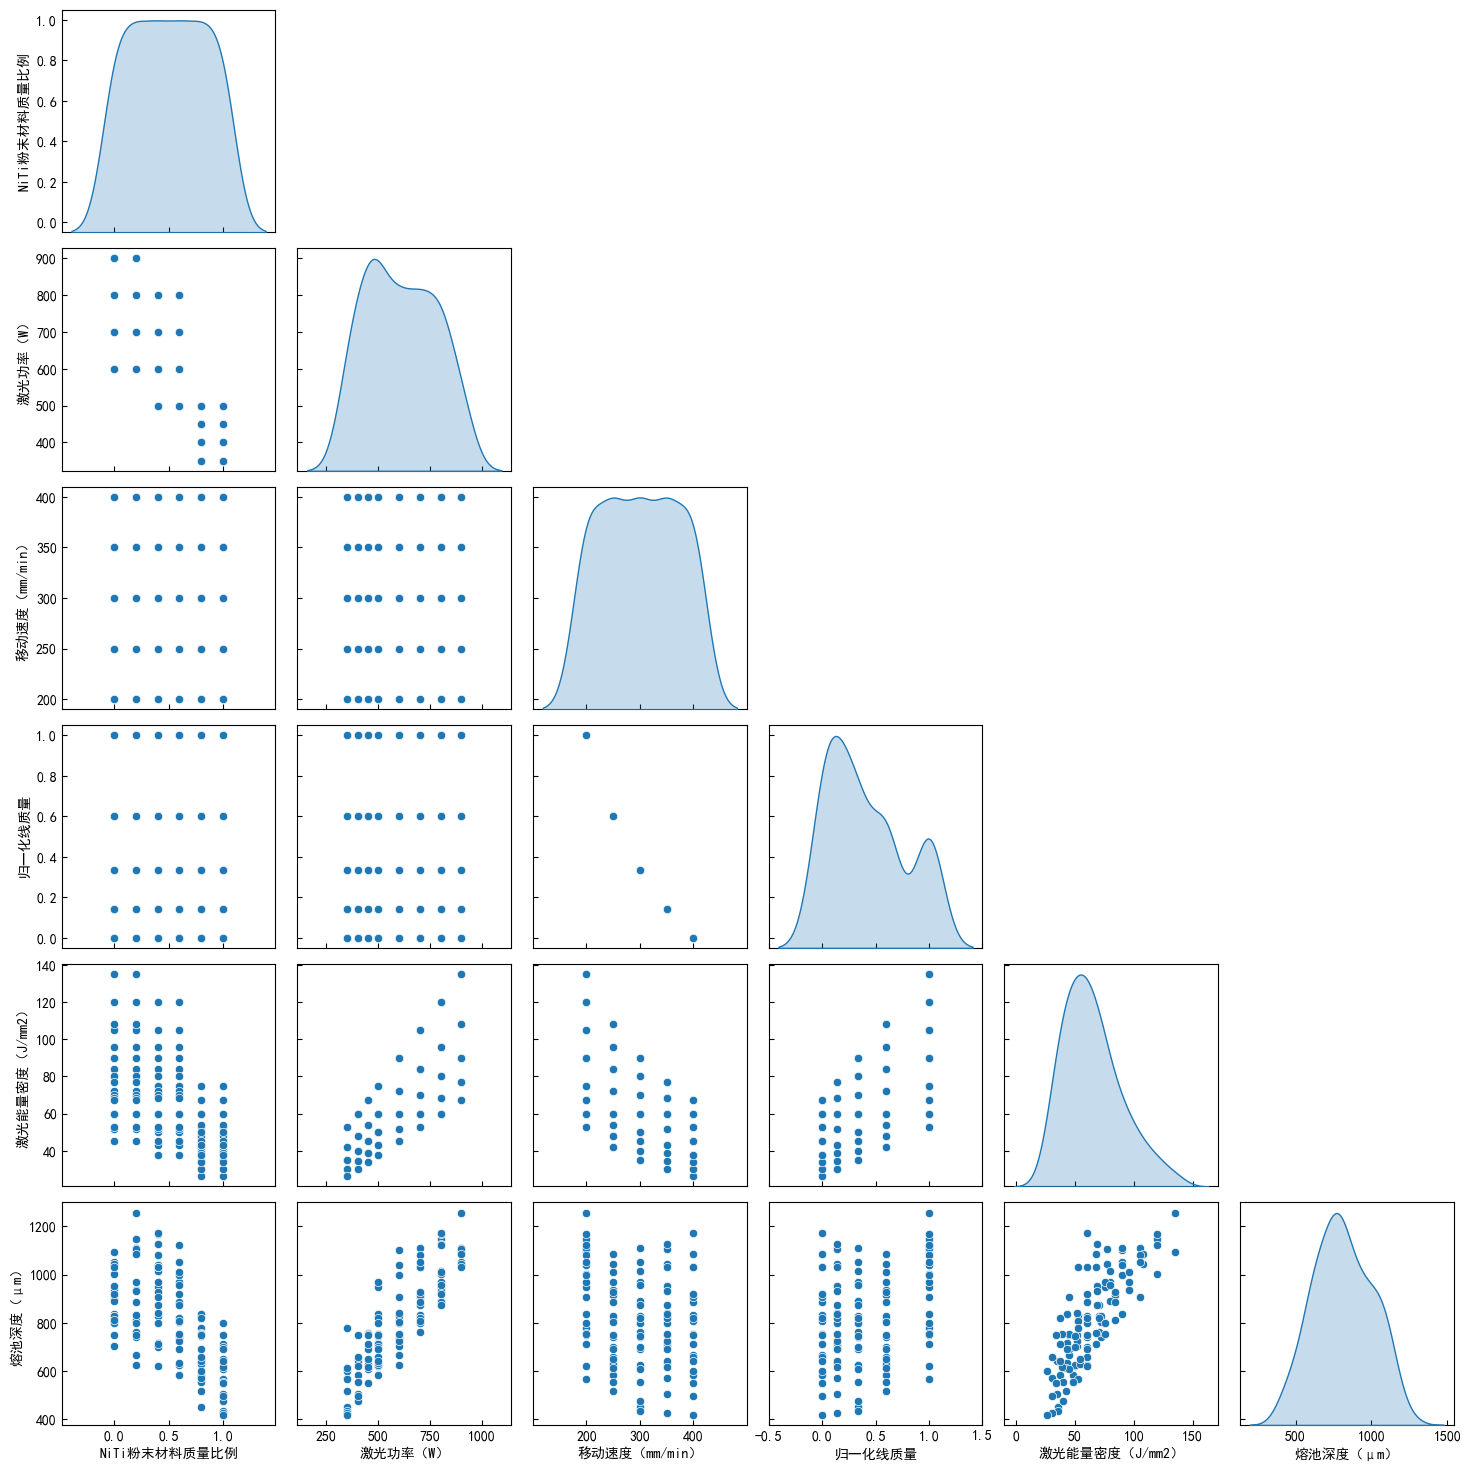

In [18]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_depth, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

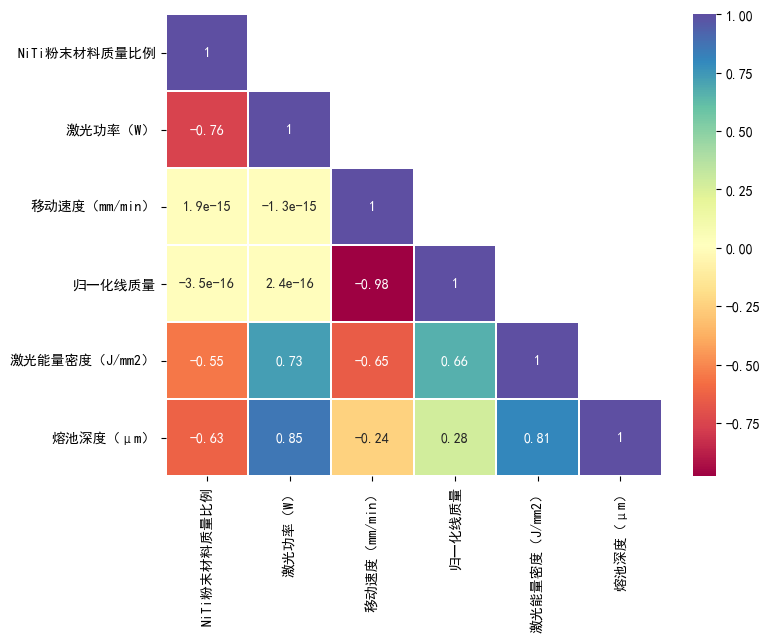

In [19]:
corr = df_depth.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [20]:
X = df_depth.iloc[:, :-1]
y = df_depth.iloc[:, -1]

In [21]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 82.1779
基准LinearRegression模型均方根误差: 75.7205
基准Lasso模型均方根误差: 82.5429
基准Ridge模型均方根误差: 78.7749
基准RandomForestRegressor模型均方根误差: 84.6494
基准SVR模型均方根误差: 73.7703
基准MLPRegressor模型均方根误差: 67.9373
基准KNeighborsRegressor模型均方根误差: 72.0009

表现最好的基准模型是: MLPRegressor，其均方根误差为: 67.9373


In [22]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 8, 'learning_rate': 0.5, 'gamma': 1, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 63.88153853604336
最佳模型在测试数据上的均方误差: 84.0023


In [23]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 5, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'thrifty'}
最佳超参数下的均方误差: 84.38788228126324
最佳模型在测试数据上的均方误差: 88.8502


In [24]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.9, 'skip_drop': 0.4, 'sample_type': 'weighted', 'rate_drop': 0.0, 'normalize_type': 'tree', 'n_estimators': 250, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 64.66690527590424
最佳模型在测试数据上的均方误差: 83.1062


## Predict Deposited Width

In [25]:
df_deposited_width = df.drop(df.columns[[0, 6, 7, 9, 10, 11]], axis=1)
df_deposited_width

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,沉积宽度（μm）
0,0.0,600,200,1.000000,90.000000,2075.6760
1,0.0,700,200,1.000000,105.000000,2428.8290
2,0.0,800,200,1.000000,120.000000,2900.9010
3,0.0,900,200,1.000000,135.000000,3189.1890
4,0.0,600,250,0.600000,72.000000,1824.0740
5,0.0,700,250,0.600000,84.000000,2301.8520
6,0.0,800,250,0.600000,96.000000,2724.3240
7,0.0,900,250,0.600000,108.000000,3099.0990
8,0.0,600,300,0.333333,60.000000,2016.8220
9,0.0,700,300,0.333333,70.000000,2366.3550


In [26]:
df_deposited_width.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,沉积宽度（μm）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,2361.604826
std,0.342997,167.574558,71.00716,0.356285,24.505039,543.593936
min,0.000000,350.000000,200.00000,0.000000,26.250000,1388.580000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,1918.941000
50%,0.500000,600.000000,300.00000,0.333333,60.000000,2335.692000
75%,0.800000,725.000000,350.00000,0.600000,77.857143,2817.754750
max,1.000000,900.000000,400.00000,1.000000,135.000000,3447.273000


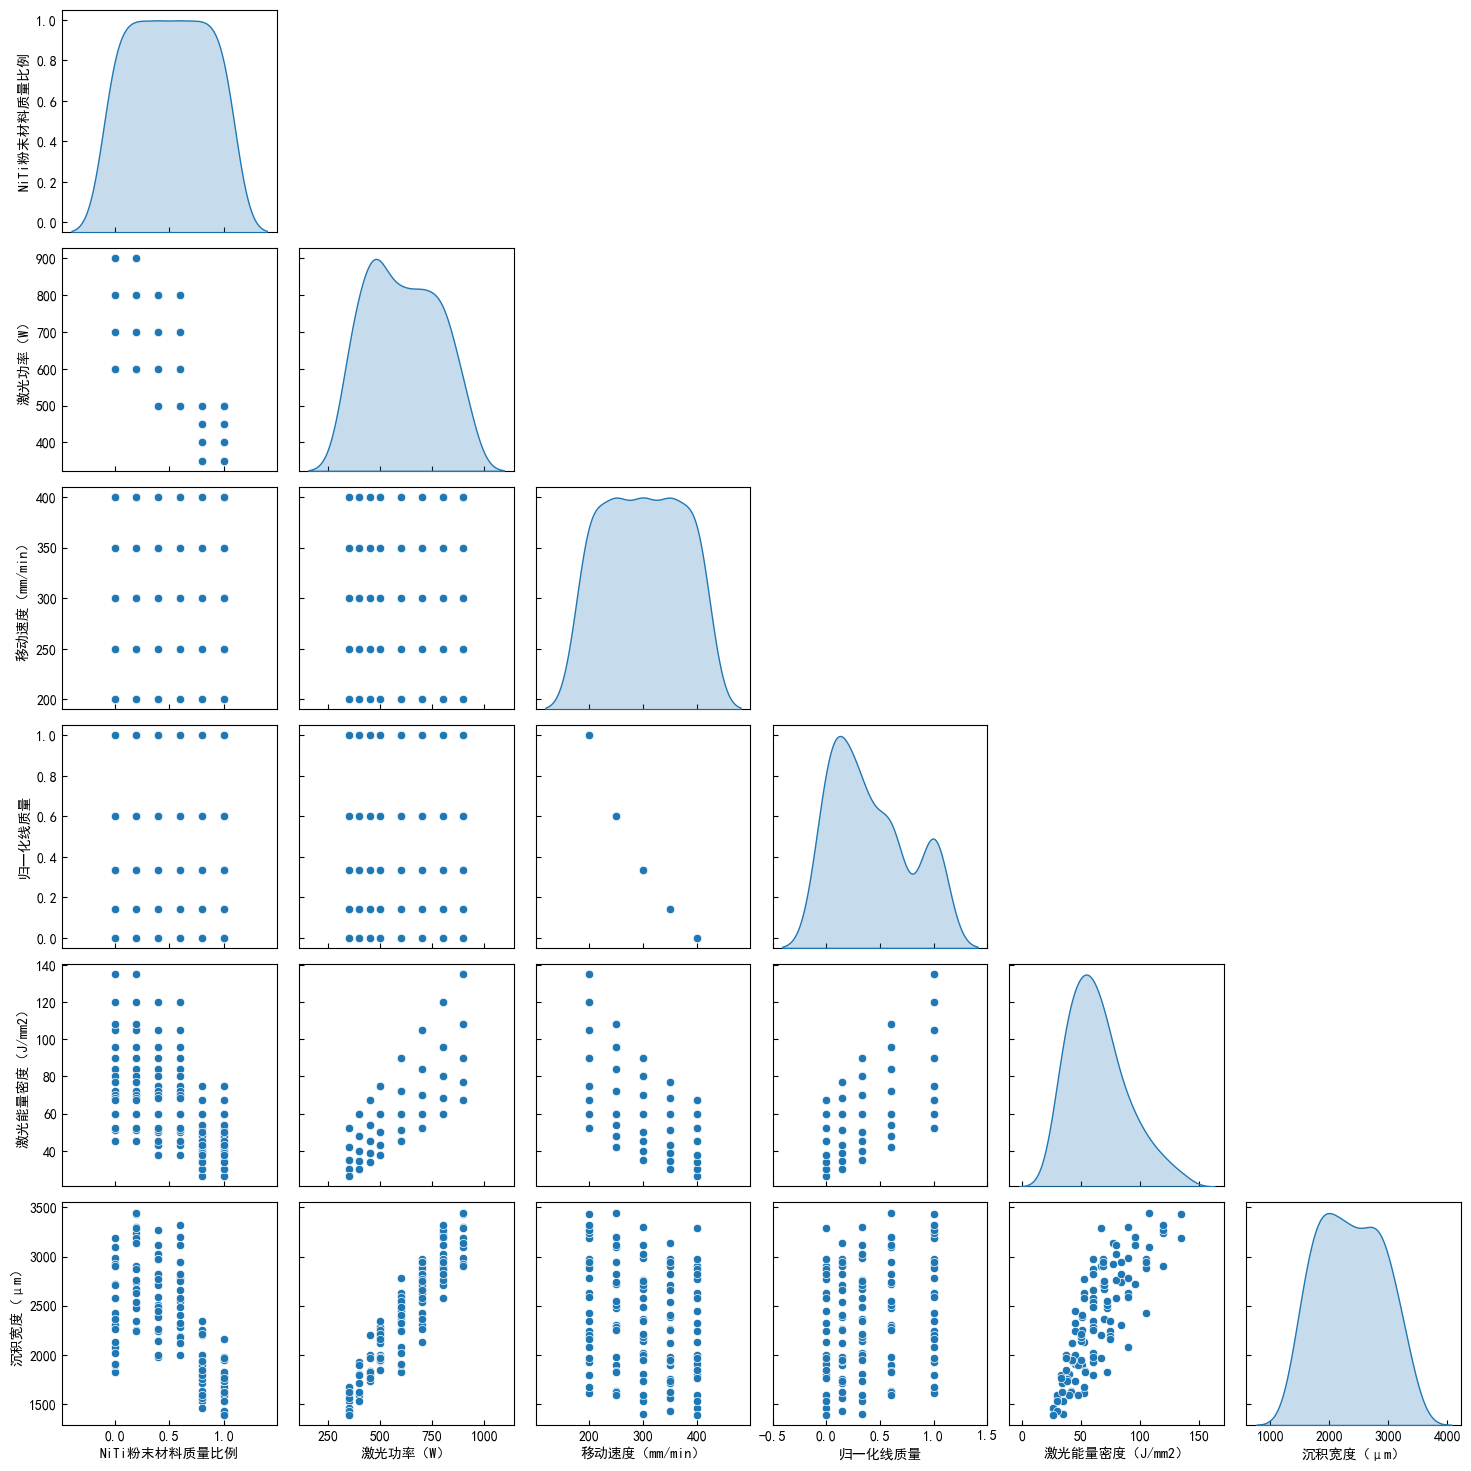

In [27]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_deposited_width, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

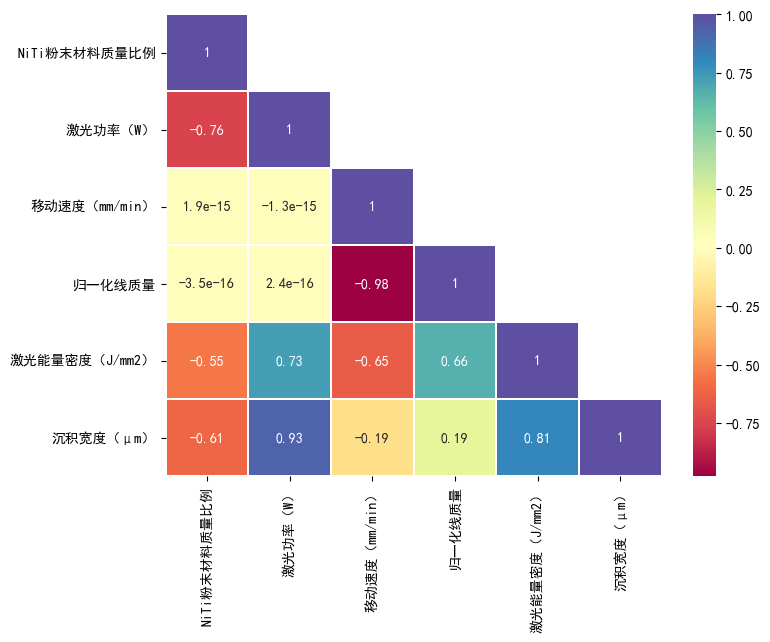

In [28]:
corr = df_deposited_width.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [29]:
X = df_deposited_width.iloc[:, :-1]
y = df_deposited_width.iloc[:, -1]

In [30]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 101.4929
基准LinearRegression模型均方根误差: 163.8229
基准Lasso模型均方根误差: 155.7404
基准Ridge模型均方根误差: 160.0265
基准RandomForestRegressor模型均方根误差: 115.3356
基准SVR模型均方根误差: 93.4557
基准MLPRegressor模型均方根误差: 105.5360
基准KNeighborsRegressor模型均方根误差: 177.4590

表现最好的基准模型是: SVR，其均方根误差为: 93.4557


In [31]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 1.0, 'n_estimators': 250, 'min_child_weight': 2, 'max_depth': 1, 'learning_rate': 0.4, 'gamma': 1, 'colsample_bytree': 0.5}
最佳超参数下的均方误差: 92.78889015236135
最佳模型在测试数据上的均方误差: 99.4514


In [32]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 8, 'reg_lambda': 0.01, 'reg_alpha': 0, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'cyclic'}
最佳超参数下的均方误差: 171.52067319675913
最佳模型在测试数据上的均方误差: 153.9598


In [33]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.8, 'skip_drop': 0.4, 'sample_type': 'weighted', 'rate_drop': 0.3, 'normalize_type': 'tree', 'n_estimators': 250, 'min_child_weight': 2, 'max_depth': 2, 'learning_rate': 0.6, 'colsample_bytree': 0.7}
最佳超参数下的均方误差: 92.11410684907081
最佳模型在测试数据上的均方误差: 90.9351


## Predict Deposited Height

In [34]:
df_deposited_height = df.drop(df.columns[[0, 6, 7, 8, 10, 11]], axis=1)
df_deposited_height

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,沉积高度（μm）
0,0.0,600,200,1.000000,90.000000,1762.162
1,0.0,700,200,1.000000,105.000000,1751.351
2,0.0,800,200,1.000000,120.000000,1888.288
3,0.0,900,200,1.000000,135.000000,1780.180
4,0.0,600,250,0.600000,72.000000,1659.259
5,0.0,700,250,0.600000,84.000000,1648.148
6,0.0,800,250,0.600000,96.000000,1517.117
7,0.0,900,250,0.600000,108.000000,1513.514
8,0.0,600,300,0.333333,60.000000,1343.925
9,0.0,700,300,0.333333,70.000000,1338.486


In [35]:
df_deposited_height.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,沉积高度（μm）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,1133.842025
std,0.342997,167.574558,71.00716,0.356285,24.505039,361.631371
min,0.000000,350.000000,200.00000,0.000000,26.250000,427.778000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,921.403250
50%,0.500000,600.000000,300.00000,0.333333,60.000000,1103.704000
75%,0.800000,725.000000,350.00000,0.600000,77.857143,1377.846250
max,1.000000,900.000000,400.00000,1.000000,135.000000,1896.364000


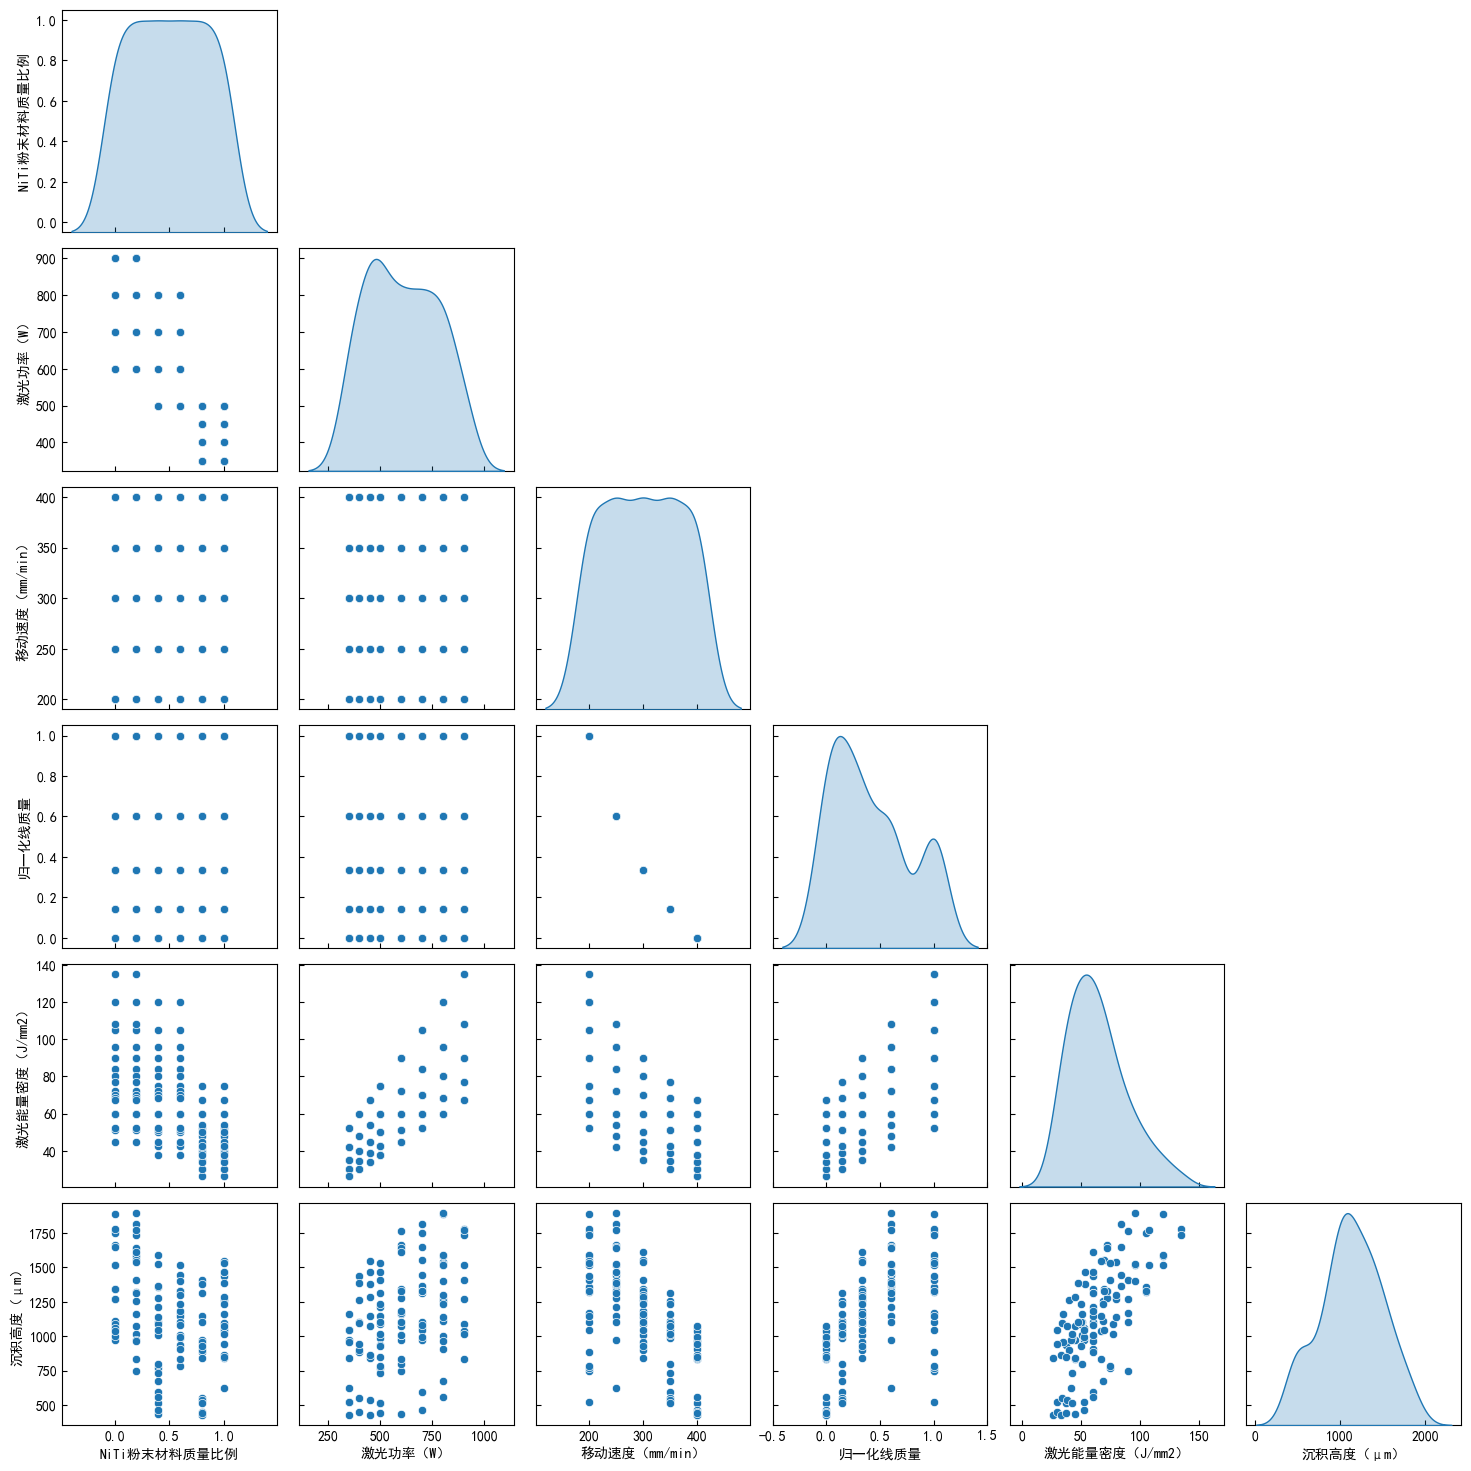

In [36]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_deposited_height, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

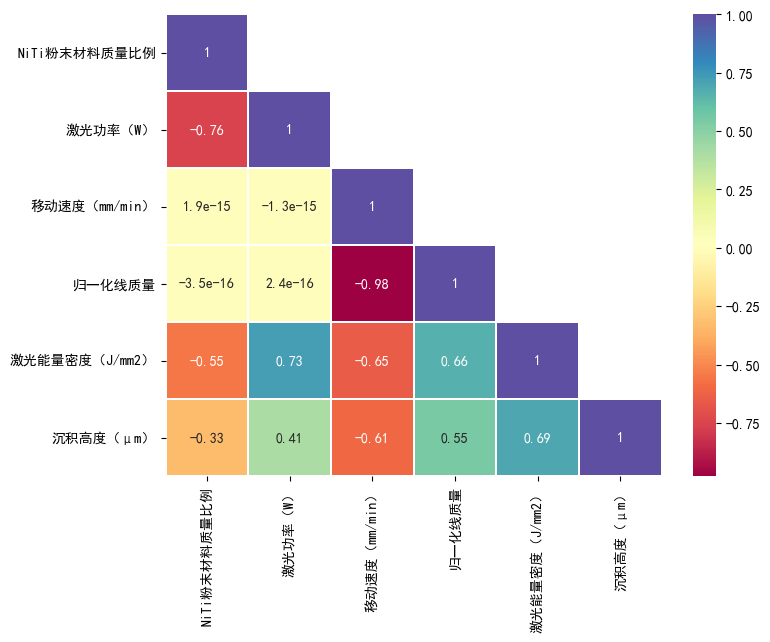

In [37]:
corr = df_deposited_height.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [38]:
X = df_deposited_height.iloc[:, :-1]
y = df_deposited_height.iloc[:, -1]

In [39]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 210.8787
基准LinearRegression模型均方根误差: 229.4309
基准Lasso模型均方根误差: 279.1159
基准Ridge模型均方根误差: 244.4641
基准RandomForestRegressor模型均方根误差: 212.8749
基准SVR模型均方根误差: 226.6678
基准MLPRegressor模型均方根误差: 198.0758
基准KNeighborsRegressor模型均方根误差: 282.5382

表现最好的基准模型是: MLPRegressor，其均方根误差为: 198.0758


In [40]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.7, 'n_estimators': 75, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.3, 'gamma': 0.25, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 178.5297053862973
最佳模型在测试数据上的均方误差: 221.3194


In [41]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 4, 'reg_lambda': 10, 'reg_alpha': 10, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'shuffle'}
最佳超参数下的均方误差: 246.99955491324894
最佳模型在测试数据上的均方误差: 262.2932


In [42]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.7, 'skip_drop': 0.4, 'sample_type': 'uniform', 'rate_drop': 0.4, 'normalize_type': 'tree', 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 179.53522973413376
最佳模型在测试数据上的均方误差: 196.8018


## Predict Left Wetting Angle

In [43]:
df_left = df.drop(df.columns[[0, 11]], axis=1)
df_left

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）
0,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,131.315
1,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,109.671
2,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,104.036
3,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,92.068
4,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,138.094
5,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,132.679
6,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,99.851
7,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,70.434
8,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,85.851
9,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,96.607


In [44]:
df_left.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,左润湿角（°）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,2814.882050,812.593842,2361.604826,1133.842025,82.600308
std,0.342997,167.574558,71.00716,0.356285,24.505039,633.983643,191.163796,543.593936,361.631371,23.734517
min,0.000000,350.000000,200.00000,0.000000,26.250000,1672.222000,418.519000,1388.580000,427.778000,29.964000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,2293.332500,664.838500,1918.941000,921.403250,68.168500
50%,0.500000,600.000000,300.00000,0.333333,60.000000,2800.867500,806.337000,2335.692000,1103.704000,82.958500
75%,0.800000,725.000000,350.00000,0.600000,77.857143,3319.342750,954.296500,2817.754750,1377.846250,96.937250
max,1.000000,900.000000,400.00000,1.000000,135.000000,4198.198000,1257.658000,3447.273000,1896.364000,138.094000


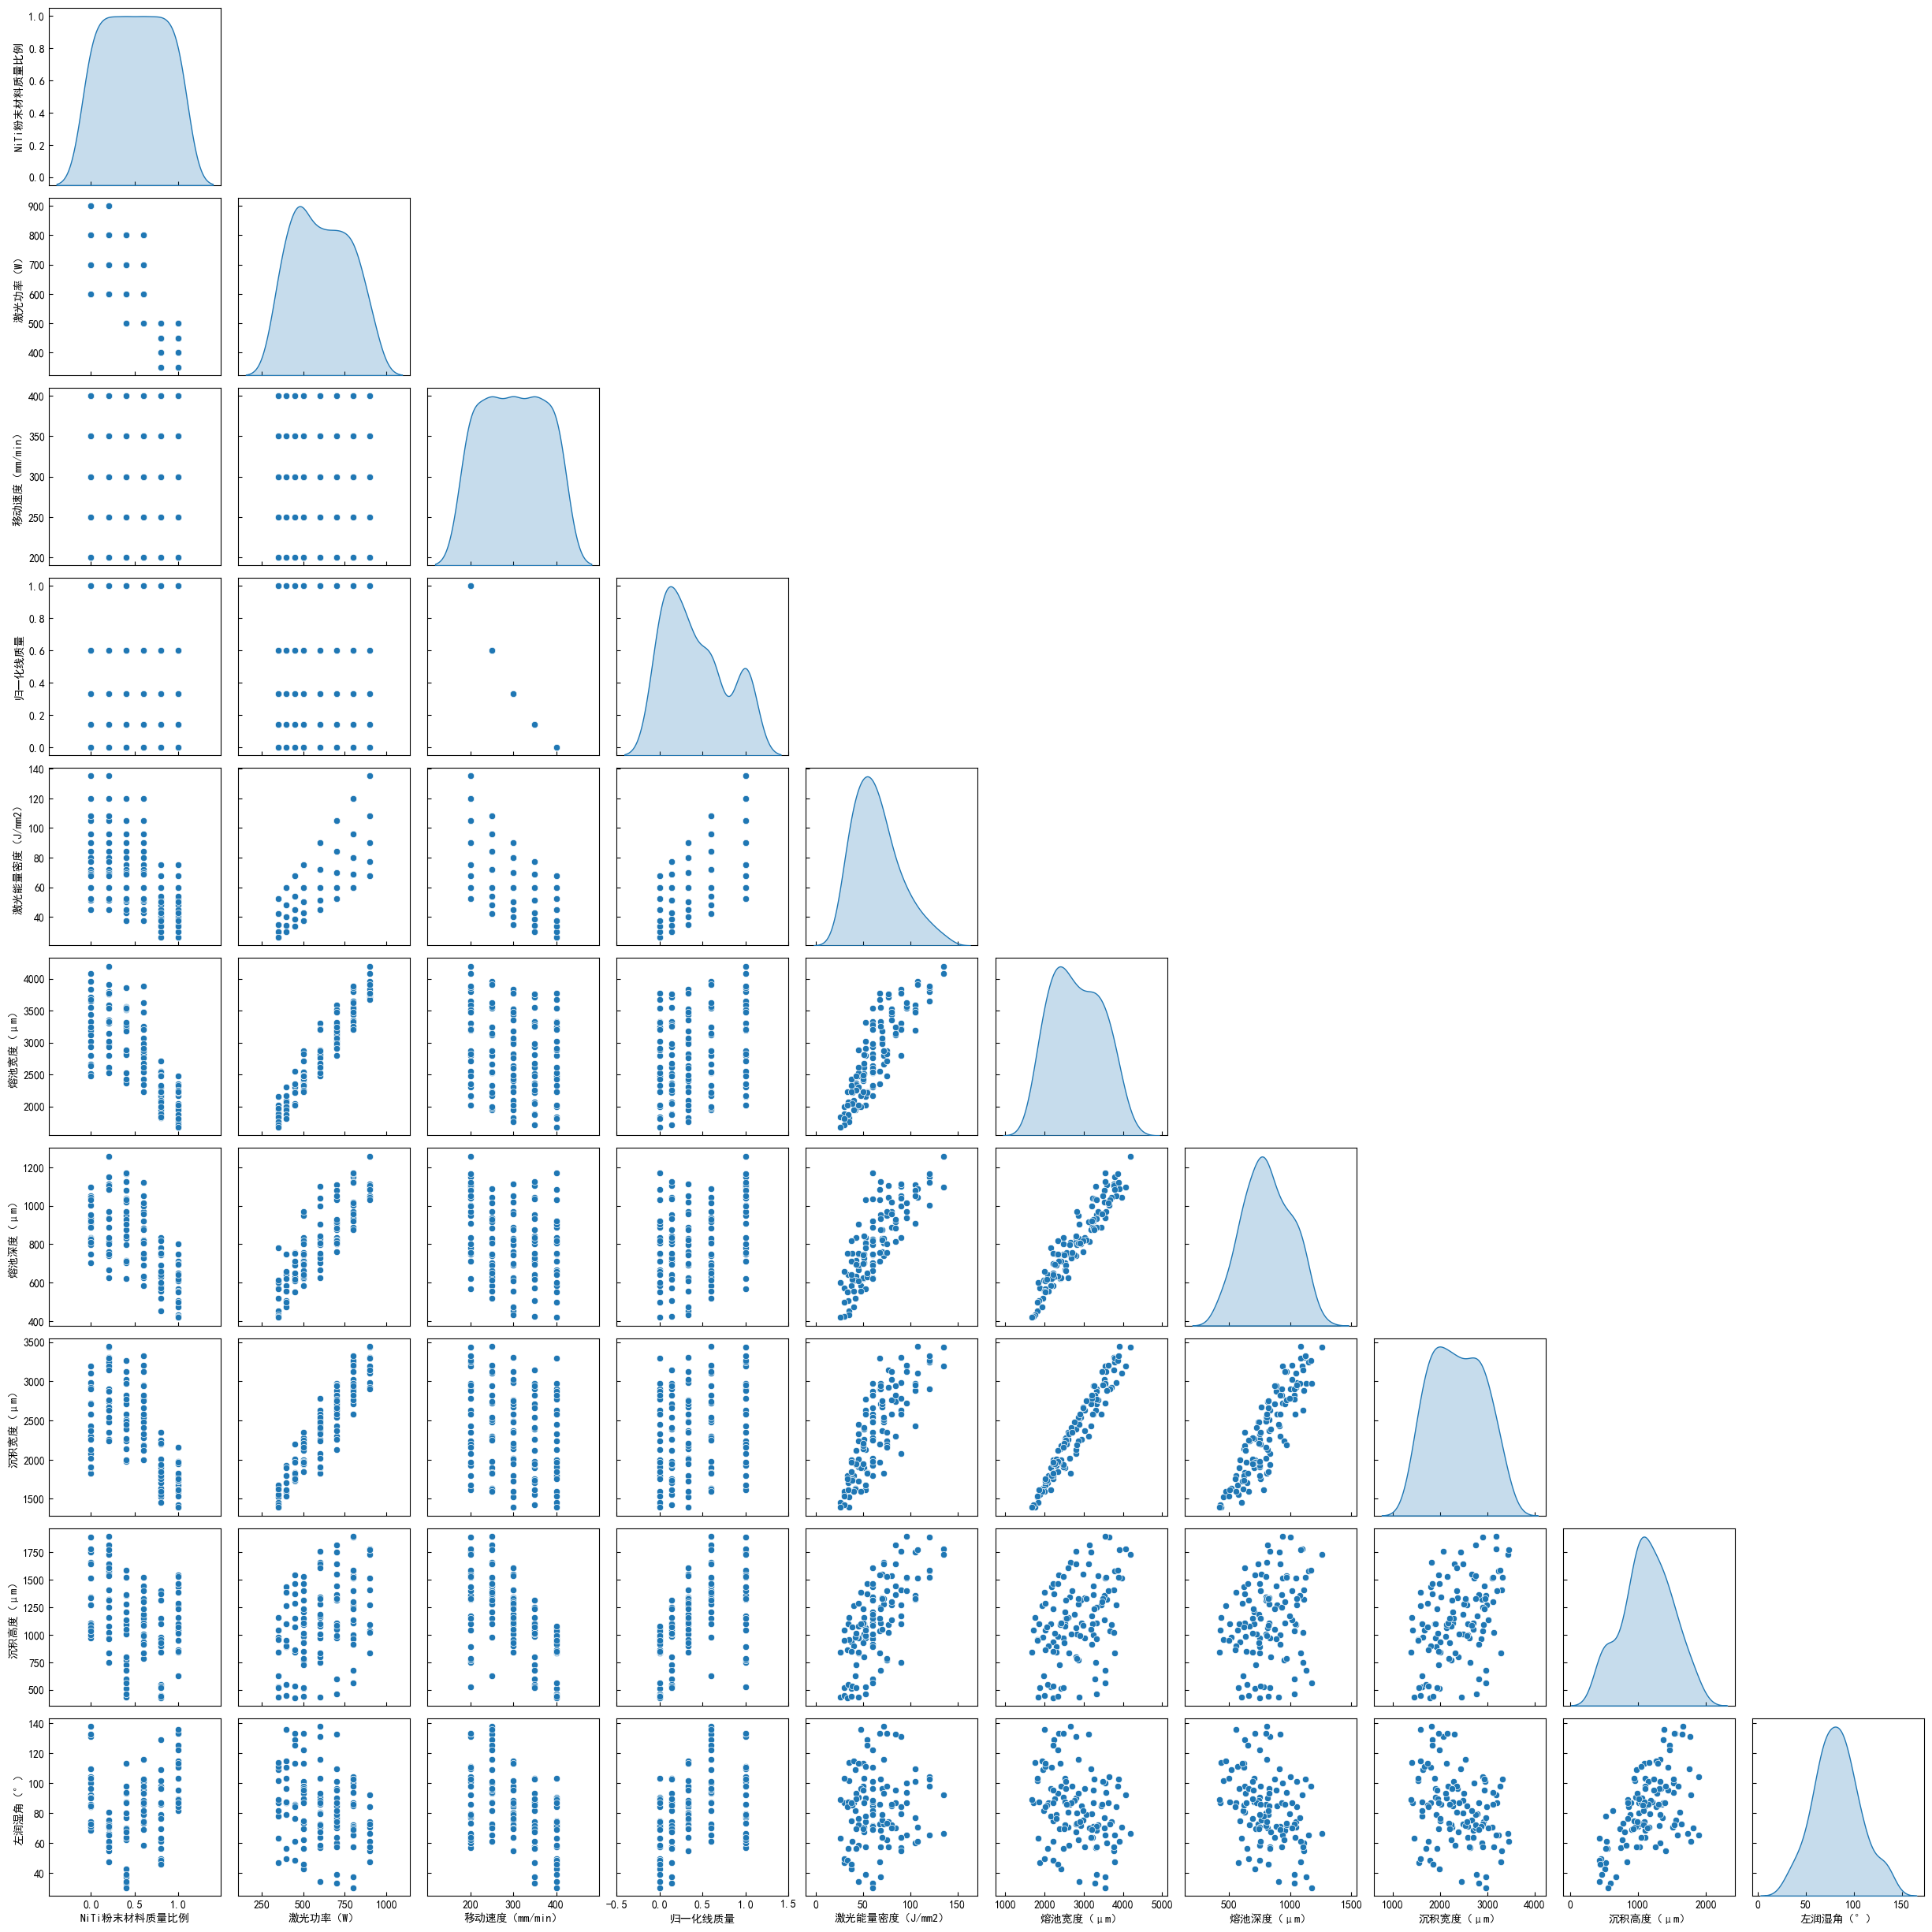

In [45]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_left, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

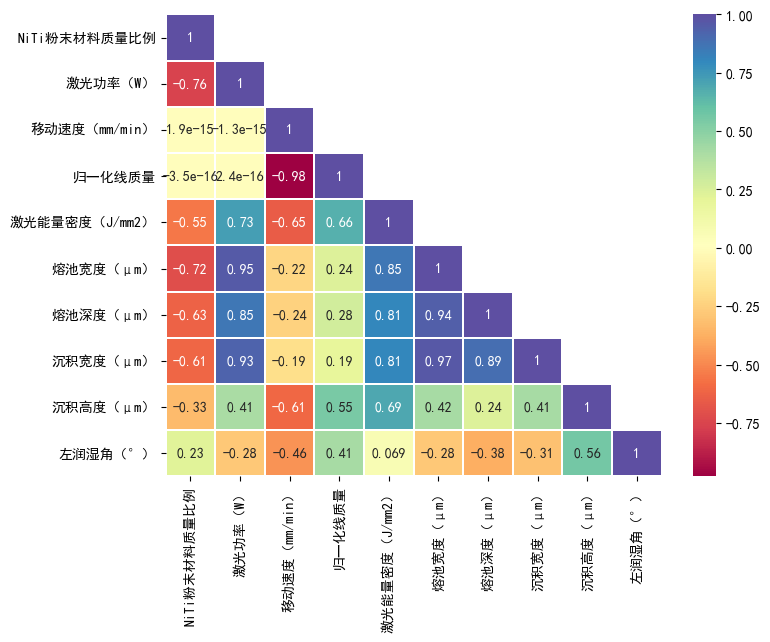

In [46]:
corr = df_left.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [47]:
X = df_left.iloc[:, :-1]
y = df_left.iloc[:, -1]

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 12.2496
基准LinearRegression模型均方根误差: 13.6771
基准Lasso模型均方根误差: 12.3674
基准Ridge模型均方根误差: 12.0823
基准RandomForestRegressor模型均方根误差: 13.9957
基准SVR模型均方根误差: 11.8736
基准MLPRegressor模型均方根误差: 9.6385
基准KNeighborsRegressor模型均方根误差: 14.6050

表现最好的基准模型是: MLPRegressor，其均方根误差为: 9.6385


In [49]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 1.0, 'n_estimators': 25, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.2, 'gamma': 1, 'colsample_bytree': 0.8}
最佳超参数下的均方误差: 11.18998545774199
最佳模型在测试数据上的均方误差: 13.4820


In [50]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'shotgun', 'top_k': 10, 'reg_lambda': 0, 'reg_alpha': 0.01, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'shuffle'}
最佳超参数下的均方误差: 13.95325705876512
最佳模型在测试数据上的均方误差: 12.1619


In [51]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.6, 'skip_drop': 0.2, 'sample_type': 'uniform', 'rate_drop': 0.2, 'normalize_type': 'tree', 'n_estimators': 75, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.3, 'colsample_bytree': 0.6}
最佳超参数下的均方误差: 11.120177496156764
最佳模型在测试数据上的均方误差: 13.1661


## Predict Right Wetting Angle

In [52]:
df_right = df.drop(df.columns[[0, 10]], axis=1)
df_right

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,右润湿角（°）
0,0.0,600,200,1.000000,90.000000,2803.604,836.036,2075.6760,1762.162,99.836
1,0.0,700,200,1.000000,105.000000,3189.189,908.108,2428.8290,1751.351,91.650
2,0.0,800,200,1.000000,120.000000,3654.054,1001.802,2900.9010,1888.288,87.592
3,0.0,900,200,1.000000,135.000000,4075.676,1095.495,3189.1890,1780.180,98.973
4,0.0,600,250,0.600000,72.000000,2661.111,807.477,1824.0740,1659.259,134.676
5,0.0,700,250,0.600000,84.000000,3124.074,914.815,2301.8520,1648.148,112.818
6,0.0,800,250,0.600000,96.000000,3549.550,936.937,2724.3240,1517.117,85.486
7,0.0,900,250,0.600000,108.000000,3960.360,1045.045,3099.0990,1513.514,87.241
8,0.0,600,300,0.333333,60.000000,2631.776,798.131,2016.8220,1343.925,128.480
9,0.0,700,300,0.333333,70.000000,3018.692,829.907,2366.3550,1338.486,81.174


In [53]:
df_right.describe()

,NiTi粉末材料质量比例,激光功率（W）,移动速度（mm/min）,归一化线质量,激光能量密度（J/mm2）,熔池宽度（μm）,熔池深度（μm）,沉积宽度（μm）,沉积高度（μm）,右润湿角（°）
count,120.000000,120.000000,120.00000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,0.500000,608.333333,300.00000,0.415238,64.570238,2814.882050,812.593842,2361.604826,1133.842025,73.919267
std,0.342997,167.574558,71.00716,0.356285,24.505039,633.983643,191.163796,543.593936,361.631371,20.509268
min,0.000000,350.000000,200.00000,0.000000,26.250000,1672.222000,418.519000,1388.580000,427.778000,29.943000
25%,0.200000,487.500000,250.00000,0.142857,45.000000,2293.332500,664.838500,1918.941000,921.403250,60.060750
50%,0.500000,600.000000,300.00000,0.333333,60.000000,2800.867500,806.337000,2335.692000,1103.704000,75.049500
75%,0.800000,725.000000,350.00000,0.600000,77.857143,3319.342750,954.296500,2817.754750,1377.846250,85.610750
max,1.000000,900.000000,400.00000,1.000000,135.000000,4198.198000,1257.658000,3447.273000,1896.364000,134.676000


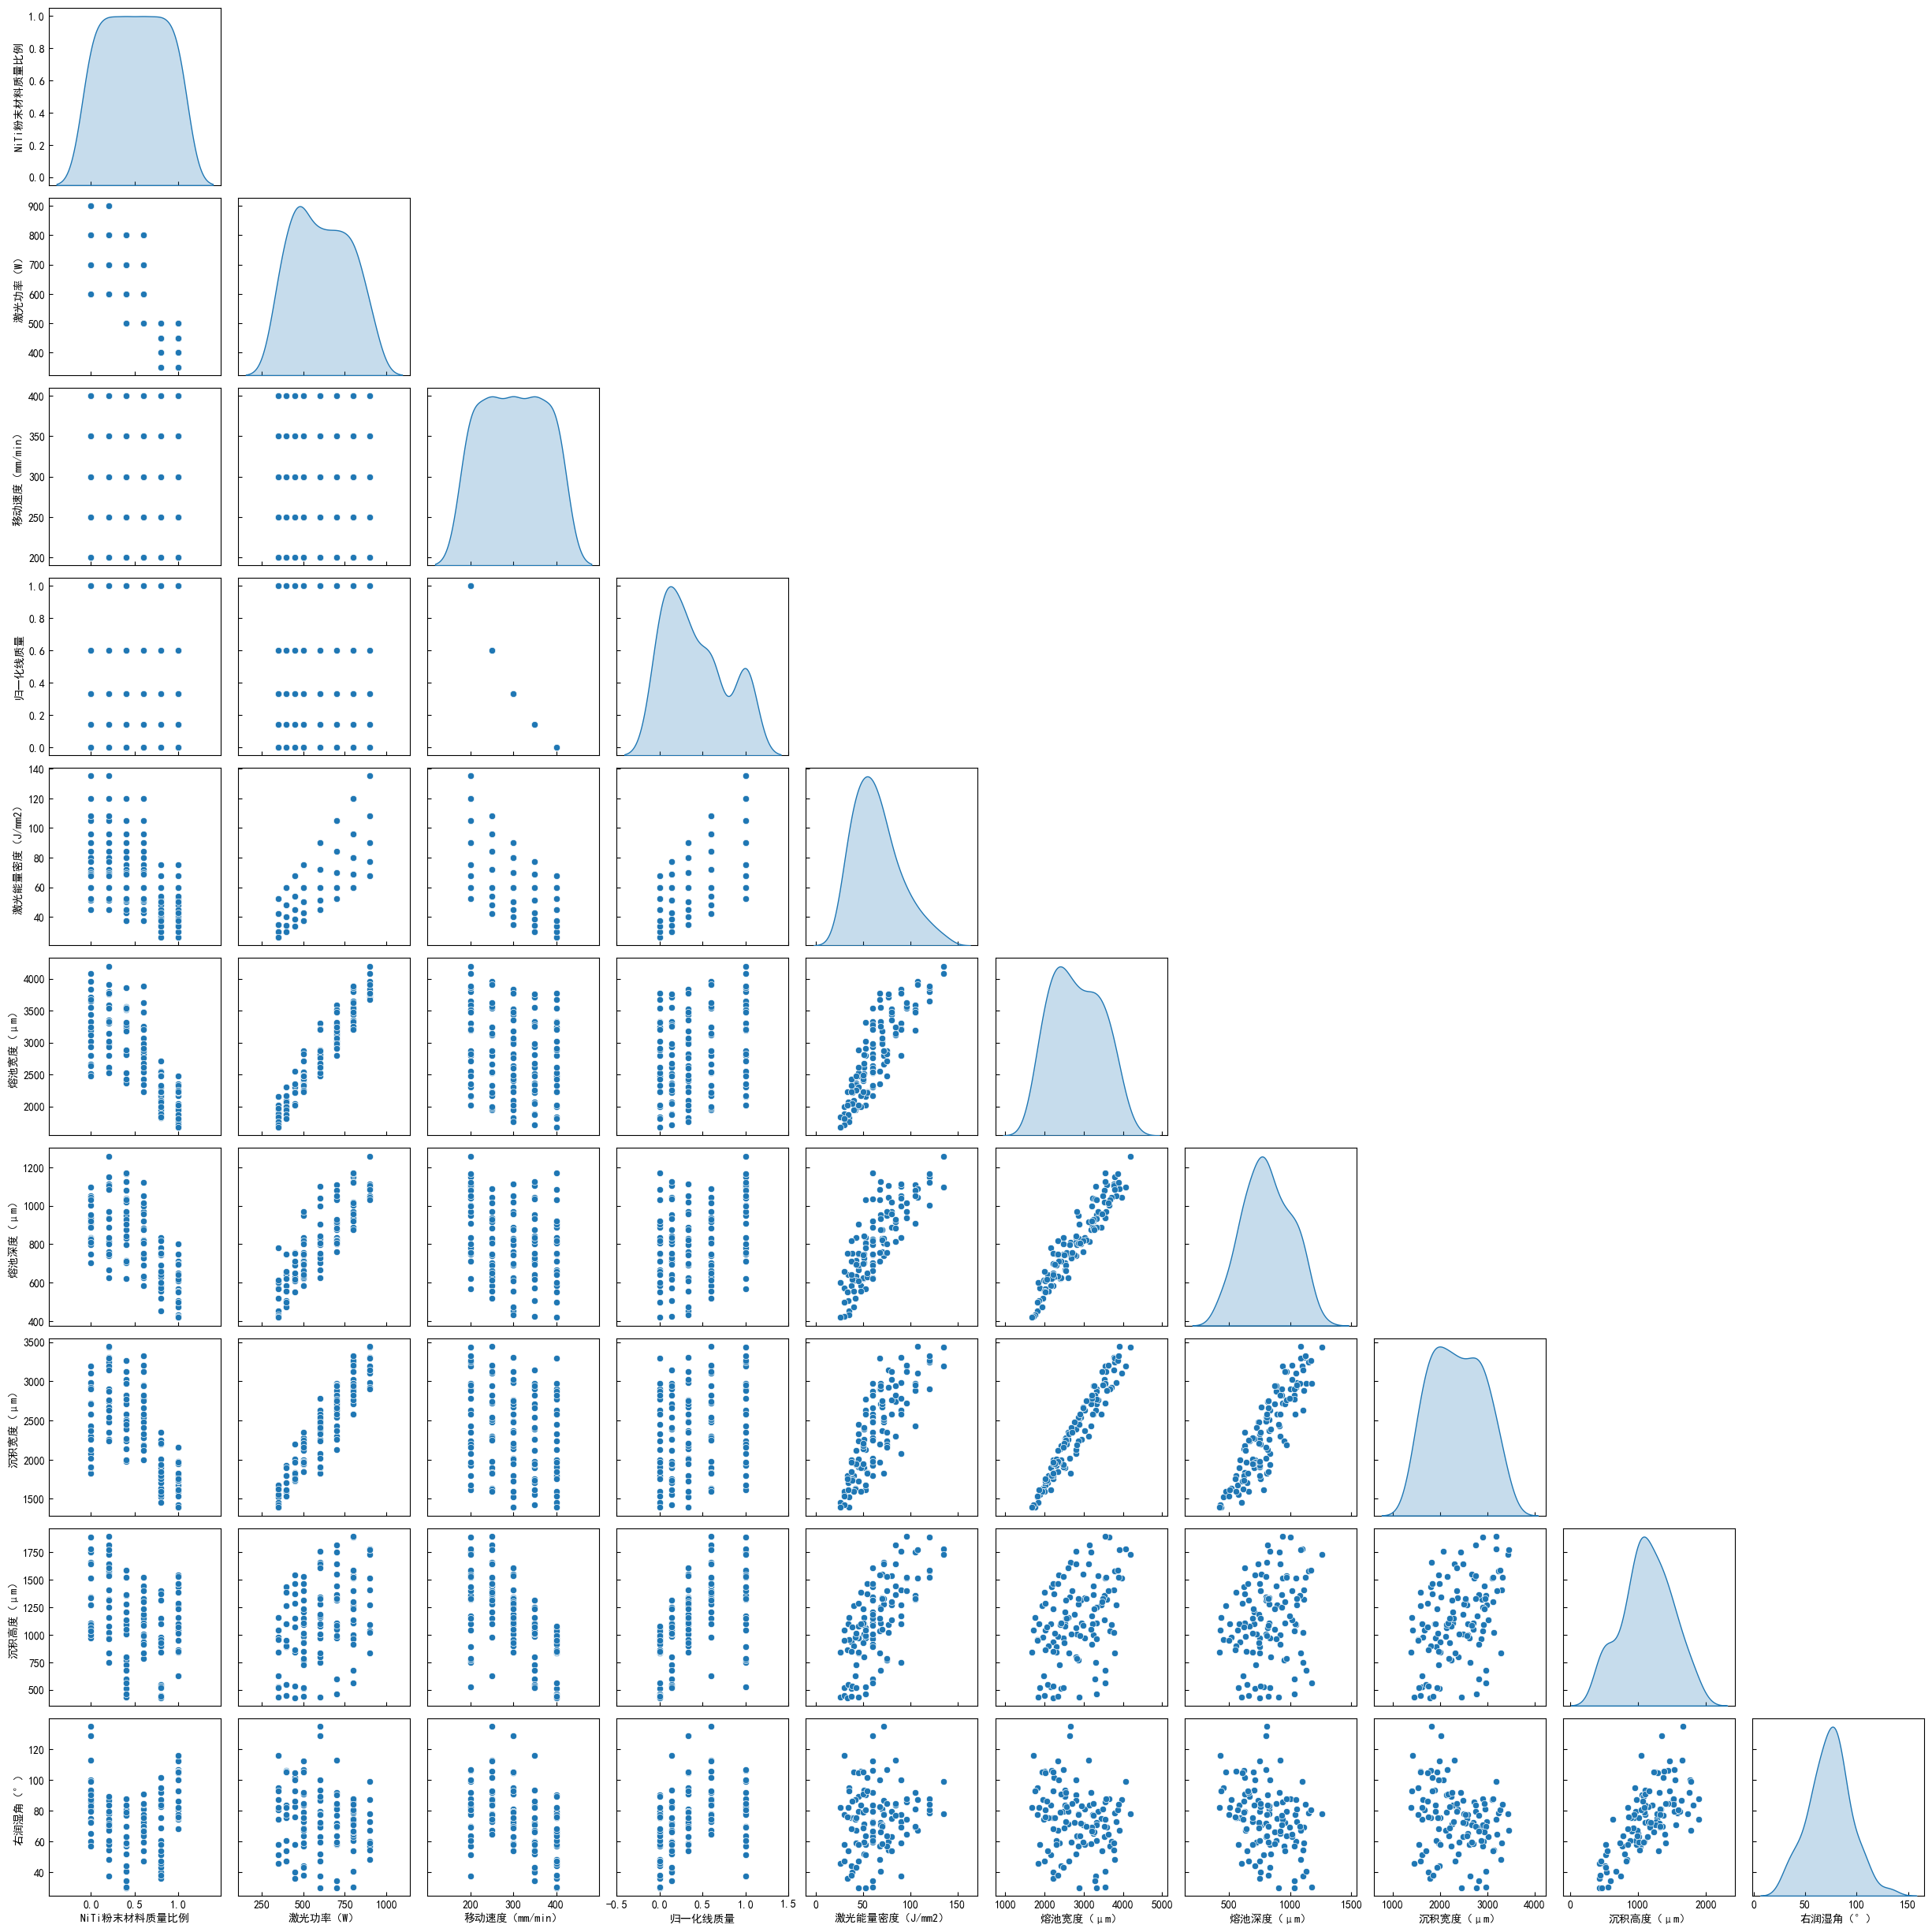

In [54]:
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
figure = sns.pairplot(df_right, diag_kind='kde')

for ax in figure.axes.flatten():
    ax.tick_params(axis='both', which='both', direction='in')  
    ax.spines['top'].set_visible(True) 
    ax.spines['right'].set_visible(True) 

for i, j in zip(*np.triu_indices_from(figure.axes, 1)): 
    figure.axes[i, j].set_visible(False)  

# for i, j in zip(*np.tril_indices_from(figure.axes, -1)): 
#     figure.axes[i, j].set_visible(False)

plt.show()

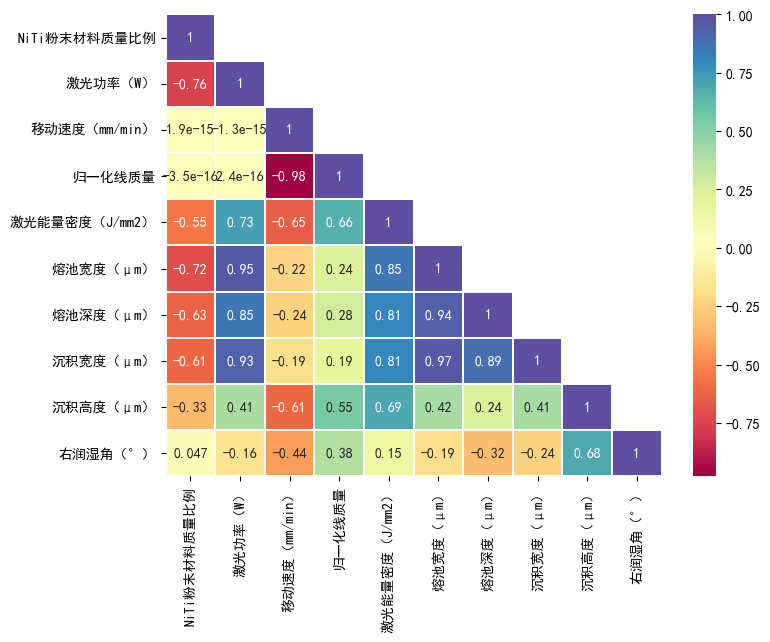

In [55]:
corr = df_right.corr()
mask = np.tril(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=~mask, annot=True, linewidths=0.1, linecolor='white', cmap='Spectral')
plt.show()

In [56]:
X = df_right.iloc[:, :-1]
y = df_right.iloc[:, -1]

In [57]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=10)

y_train = y_train.reshape(-1) if isinstance(y_train, np.ndarray) else y_train.values
y_test = y_test.reshape(-1) if isinstance(y_test, np.ndarray) else y_test.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() 
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

models = {
    'XGBRegressor': XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10),
    'LinearRegression': LinearRegression(),
    'Lasso': Lasso(alpha=0.1, random_state=10),
    'Ridge': Ridge(alpha=1.0, random_state=10),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=10),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(32,64,128), max_iter=100000, random_state=10), 
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=5)
}

rmse_results = {}

for name, model in models.items():
    if name in ['LinearRegression', 'Lasso', 'Ridge', 'SVR', 'MLPRegressor', 'KNeighborsRegressor']:
        model.fit(X_train_scaled, y_train_scaled)  
        y_pred_scaled = model.predict(X_test_scaled)  
        y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_results[name] = rmse
    print(f'基准{name}模型均方根误差: {rmse:.4f}')


best_model_name = min(rmse_results, key=rmse_results.get)
best_rmse = rmse_results[best_model_name]
print(f'\n表现最好的基准模型是: {best_model_name}，其均方根误差为: {best_rmse:.4f}')

基准XGBRegressor模型均方根误差: 6.8185
基准LinearRegression模型均方根误差: 11.0200
基准Lasso模型均方根误差: 9.5201
基准Ridge模型均方根误差: 10.5001
基准RandomForestRegressor模型均方根误差: 6.2379
基准SVR模型均方根误差: 7.9172
基准MLPRegressor模型均方根误差: 9.4649
基准KNeighborsRegressor模型均方根误差: 10.5296

表现最好的基准模型是: RandomForestRegressor，其均方根误差为: 6.2379


In [58]:
xgb_model = XGBRegressor(booster='gbtree', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250],
    'gamma':[0, 0.1, 0.25, 0.5, 0.75, 1, 2, 5],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
    'min_child_weight':[1, 2, 3, 4, 5, 6],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.5, 'n_estimators': 25, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.2, 'gamma': 2, 'colsample_bytree': 0.7}
最佳超参数下的均方误差: 9.914758040409318
最佳模型在测试数据上的均方误差: 8.7562


In [59]:
xgb_model = XGBRegressor(booster='gblinear', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [25, 50, 100, 150, 200, 250, 300],  
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5], 
    'reg_lambda': [0, 0.01, 0.1, 0.5, 1, 5, 10],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5, 10], 
    'updater': ['shotgun', 'coord_descent'],
    'feature_selector': ['cyclic', 'shuffle', 'random', 'greedy', 'thrifty'],
    'top_k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'updater': 'coord_descent', 'top_k': 8, 'reg_lambda': 5, 'reg_alpha': 10, 'n_estimators': 300, 'learning_rate': 0.5, 'feature_selector': 'thrifty'}
最佳超参数下的均方误差: 9.668122103868003
最佳模型在测试数据上的均方误差: 9.3820


In [60]:
xgb_model = XGBRegressor(booster='dart', objective='reg:squarederror', random_state=10)

param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150, 200, 250, 300], 
    'learning_rate': [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6], 
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8], 
    'min_child_weight': [1, 2, 3, 4, 5], 
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],  
    'rate_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'skip_drop': [0.0, 0.1, 0.2, 0.3, 0.4],  
    'sample_type': ['uniform', 'weighted'],  
    'normalize_type': ['tree', 'forest'] 
}

best_model = model_with_random_search(X_train, y_train, model=xgb_model, param_dist=param_dist)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'最佳模型在测试数据上的均方误差: {rmse:.4f}')

Fitting 4 folds for each of 5000 candidates, totalling 20000 fits
最优超参数: {'subsample': 0.7, 'skip_drop': 0.3, 'sample_type': 'uniform', 'rate_drop': 0.2, 'normalize_type': 'forest', 'n_estimators': 300, 'min_child_weight': 4, 'max_depth': 4, 'learning_rate': 0.5, 'colsample_bytree': 1.0}
最佳超参数下的均方误差: 9.806328413054498
最佳模型在测试数据上的均方误差: 6.5671
